<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearning/blob/master/DeepLearning/10_Advanced_Optimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

# Global seed — re-applied before every training run so each optimizer
# starts from identical weight initialization and sees the same shuffle order.
SEED = 42
tf.keras.utils.set_random_seed(SEED)

TensorFlow version: 2.19.0
GPU available: True


In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test,  10)

class_names = ['airplane', 'automobile', 'bird',  'cat',  'deer',
               'dog',      'frog',       'horse', 'ship', 'truck']

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape}, y_test:  {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 27s 0us/step
x_train: (50000, 32, 32, 3), y_train: (50000, 10)
x_test:  (10000, 32, 32, 3), y_test:  (10000, 10)


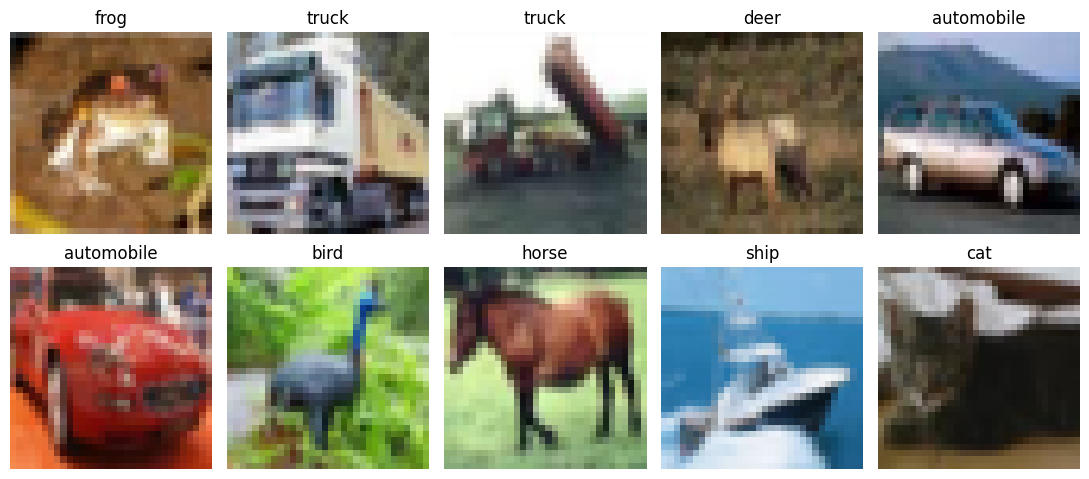

In [ ]:
# Peek at a handful of images
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[int(np.argmax(y_train[i]))])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# def build_model():
#     model = keras.Sequential([
#         layers.Input(shape=(32, 32, 3)),
#         layers.Flatten(), # Flatten the input image
#         layers.Dense(512, activation='relu'),
#         layers.Dropout(0.3),
#         layers.Dense(256, activation='relu'),
#         layers.Dropout(0.3),
#         layers.Dense(10, activation='softmax'), # Output layer for 10 classes
#     ])
#     return model

# build_model().summary()


def build_model():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax'),
    ])
    return model

build_model().summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,898 (1.38 MB)

 Trainable params: 361,898 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS      = 15
BATCH_SIZE  = 128

histories = {}

def train_with(optimizer, name):
    # Reset all RNGs so weight init + shuffling are identical across runs.
    tf.keras.utils.set_random_seed(SEED)

    model = build_model()
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    print(f"\n=== Training with {name} ===")
    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=2,
    )
    histories[name] = history.history
    return history

In [ ]:
train_with(keras.optimizers.SGD(learning_rate=0.01), 'SGD')


=== Training with SGD ===
Epoch 1/15
391/391 - 13s - 32ms/step - accuracy: 0.1284 - loss: 2.2927 - val_accuracy: 0.1822 - val_loss: 2.2669
Epoch 2/15
391/391 - 4s - 9ms/step - accuracy: 0.2134 - loss: 2.1623 - val_accuracy: 0.2849 - val_loss: 2.0137
Epoch 3/15
391/391 - 4s - 9ms/step - accuracy: 0.2709 - loss: 2.0056 - val_accuracy: 0.3210 - val_loss: 1.9143
Epoch 4/15
391/391 - 4s - 10ms/step - accuracy: 0.3051 - loss: 1.9215 - val_accuracy: 0.3425 - val_loss: 1.8220
Epoch 5/15
391/391 - 4s - 9ms/step - accuracy: 0.3448 - loss: 1.8228 - val_accuracy: 0.4007 - val_loss: 1.7039
Epoch 6/15
391/391 - 4s - 9ms/step - accuracy: 0.3812 - loss: 1.7235 - val_accuracy: 0.4221 - val_loss: 1.6272
Epoch 7/15
391/391 - 4s - 10ms/step - accuracy: 0.4099 - loss: 1.6403 - val_accuracy: 0.4462 - val_loss: 1.5590
Epoch 8/15
391/391 - 4s - 10ms/step - accuracy: 0.4332 - loss: 1.5808 - val_accuracy: 0.4750 - val_loss: 1.4953
Epoch 9/15
391/391 - 4s - 9ms/step - accuracy: 0.4532 - loss: 1.5253 - val_accur

In [ ]:
train_with(keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), 'Momentum')


=== Training with Momentum ===
Epoch 1/15
391/391 - 10s - 25ms/step - accuracy: 0.2619 - loss: 2.0087 - val_accuracy: 0.4060 - val_loss: 1.6323
Epoch 2/15
391/391 - 4s - 10ms/step - accuracy: 0.4371 - loss: 1.5561 - val_accuracy: 0.5031 - val_loss: 1.3747
Epoch 3/15
391/391 - 4s - 10ms/step - accuracy: 0.5162 - loss: 1.3473 - val_accuracy: 0.5645 - val_loss: 1.2322
Epoch 4/15
391/391 - 4s - 10ms/step - accuracy: 0.5681 - loss: 1.2152 - val_accuracy: 0.6089 - val_loss: 1.1033
Epoch 5/15
391/391 - 4s - 9ms/step - accuracy: 0.6102 - loss: 1.0976 - val_accuracy: 0.6350 - val_loss: 1.0387
Epoch 6/15
391/391 - 4s - 9ms/step - accuracy: 0.6467 - loss: 1.0008 - val_accuracy: 0.6440 - val_loss: 1.0159
Epoch 7/15
391/391 - 4s - 10ms/step - accuracy: 0.6801 - loss: 0.9076 - val_accuracy: 0.6829 - val_loss: 0.8988
Epoch 8/15
391/391 - 4s - 9ms/step - accuracy: 0.7077 - loss: 0.8339 - val_accuracy: 0.6881 - val_loss: 0.9019
Epoch 9/15
391/391 - 4s - 9ms/step - accuracy: 0.7323 - loss: 0.7659 - val

In [ ]:
train_with(keras.optimizers.RMSprop(learning_rate=0.001), 'RMSprop')


=== Training with RMSprop ===
Epoch 1/15
391/391 - 10s - 25ms/step - accuracy: 0.3551 - loss: 1.7774 - val_accuracy: 0.4752 - val_loss: 1.4369
Epoch 2/15
391/391 - 4s - 10ms/step - accuracy: 0.5172 - loss: 1.3599 - val_accuracy: 0.6001 - val_loss: 1.1393
Epoch 3/15
391/391 - 4s - 10ms/step - accuracy: 0.6043 - loss: 1.1332 - val_accuracy: 0.6082 - val_loss: 1.1145
Epoch 4/15
391/391 - 4s - 9ms/step - accuracy: 0.6581 - loss: 0.9794 - val_accuracy: 0.6709 - val_loss: 0.9470
Epoch 5/15
391/391 - 4s - 9ms/step - accuracy: 0.7018 - loss: 0.8620 - val_accuracy: 0.6818 - val_loss: 0.9226
Epoch 6/15
391/391 - 4s - 11ms/step - accuracy: 0.7314 - loss: 0.7718 - val_accuracy: 0.7249 - val_loss: 0.8202
Epoch 7/15
391/391 - 4s - 10ms/step - accuracy: 0.7560 - loss: 0.6966 - val_accuracy: 0.7480 - val_loss: 0.7482
Epoch 8/15
391/391 - 4s - 9ms/step - accuracy: 0.7830 - loss: 0.6274 - val_accuracy: 0.7495 - val_loss: 0.7688
Epoch 9/15
391/391 - 4s - 10ms/step - accuracy: 0.8021 - loss: 0.5716 - val

In [ ]:
train_with(keras.optimizers.Adam(learning_rate=0.001), 'Adam')


=== Training with Adam ===
Epoch 1/15
391/391 - 11s - 29ms/step - accuracy: 0.4020 - loss: 1.6317 - val_accuracy: 0.5470 - val_loss: 1.2463
Epoch 2/15
391/391 - 4s - 10ms/step - accuracy: 0.5619 - loss: 1.2277 - val_accuracy: 0.6297 - val_loss: 1.0392
Epoch 3/15
391/391 - 4s - 9ms/step - accuracy: 0.6308 - loss: 1.0467 - val_accuracy: 0.6679 - val_loss: 0.9464
Epoch 4/15
391/391 - 4s - 9ms/step - accuracy: 0.6782 - loss: 0.9239 - val_accuracy: 0.7059 - val_loss: 0.8397
Epoch 5/15
391/391 - 4s - 11ms/step - accuracy: 0.7094 - loss: 0.8294 - val_accuracy: 0.7257 - val_loss: 0.7824
Epoch 6/15
391/391 - 4s - 10ms/step - accuracy: 0.7311 - loss: 0.7643 - val_accuracy: 0.7209 - val_loss: 0.8194
Epoch 7/15
391/391 - 4s - 10ms/step - accuracy: 0.7515 - loss: 0.7077 - val_accuracy: 0.7231 - val_loss: 0.8149
Epoch 8/15
391/391 - 4s - 10ms/step - accuracy: 0.7655 - loss: 0.6585 - val_accuracy: 0.7304 - val_loss: 0.8127
Epoch 9/15
391/391 - 4s - 10ms/step - accuracy: 0.7827 - loss: 0.6165 - val_a

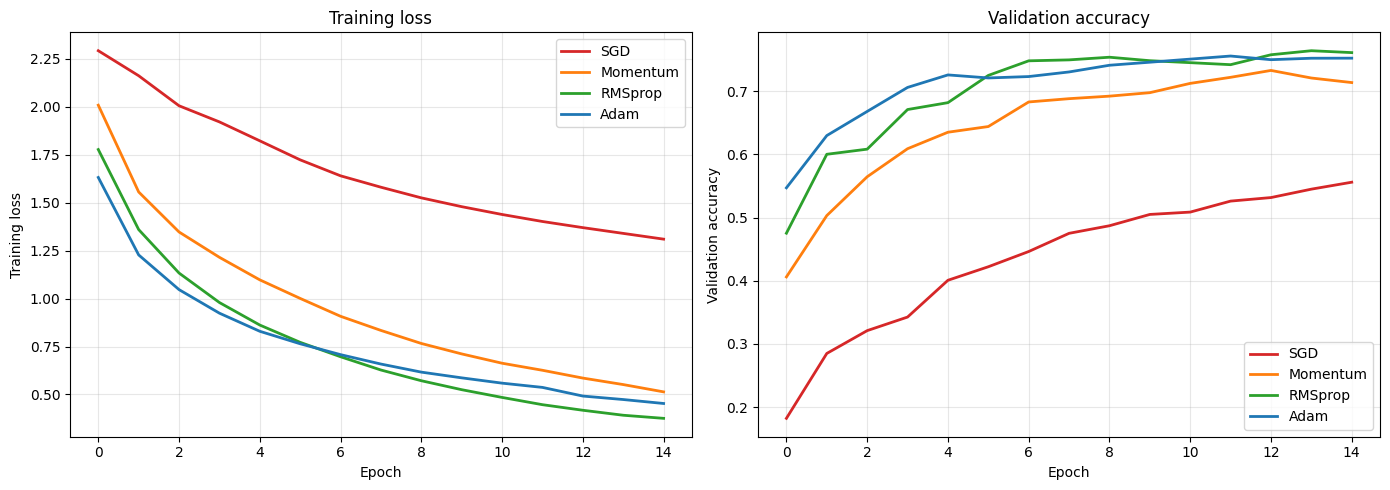

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'SGD': '#d62728', 'Momentum': '#ff7f0e',
          'RMSprop': '#2ca02c', 'Adam': '#1f77b4'}

for name, h in histories.items():
    axes[0].plot(h['loss'],         label=name, color=colors.get(name), linewidth=2)
    axes[1].plot(h['val_accuracy'], label=name, color=colors.get(name), linewidth=2)

axes[0].set(xlabel='Epoch', ylabel='Training loss', title='Training loss')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].set(xlabel='Epoch', ylabel='Validation accuracy', title='Validation accuracy')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger,
)

ARTIFACTS = Path('artifacts')
ARTIFACTS.mkdir(exist_ok=True)

CKPT_PATH = ARTIFACTS / 'best_model.keras'
LOG_PATH  = ARTIFACTS / 'training_log.csv'

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=str(CKPT_PATH),
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    CSVLogger(str(LOG_PATH)),
]

for cb in callbacks:
    print(f"  - {type(cb).__name__}")

  - EarlyStopping
  - ModelCheckpoint
  - ReduceLROnPlateau
  - CSVLogger


In [ ]:
MAX_EPOCHS = 50

tf.keras.utils.set_random_seed(SEED)

clean_model = build_model()
clean_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

clean_history = clean_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2,
)

print(f"\nStopped after {len(clean_history.history['loss'])} epochs "
      f"(cap was {MAX_EPOCHS}).")

Epoch 1/50

Epoch 1: val_loss improved from None to 1.24526, saving model to artifacts/best_model.keras

Epoch 1: finished saving model to artifacts/best_model.keras
391/391 - 11s - 29ms/step - accuracy: 0.4018 - loss: 1.6327 - val_accuracy: 0.5577 - val_loss: 1.2453 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss improved from 1.24526 to 1.05186, saving model to artifacts/best_model.keras

Epoch 2: finished saving model to artifacts/best_model.keras
391/391 - 4s - 10ms/step - accuracy: 0.5664 - loss: 1.2148 - val_accuracy: 0.6243 - val_loss: 1.0519 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss improved from 1.05186 to 0.91065, saving model to artifacts/best_model.keras

Epoch 3: finished saving model to artifacts/best_model.keras
391/391 - 4s - 10ms/step - accuracy: 0.6370 - loss: 1.0290 - val_accuracy: 0.6762 - val_loss: 0.9107 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_loss improved from 0.91065 to 0.85217, saving model to artifacts/best_model.keras

Epoch 4: fin

In [ ]:
import pandas as pd

df = pd.read_csv('artifacts/training_log.csv')
df.head()

,epoch,accuracy,learning_rate,loss,val_accuracy,val_loss
0,0,0.40176,0.001,1.632675,0.5577,1.245261
1,1,0.56644,0.001,1.214799,0.6243,1.051863
2,2,0.63698,0.001,1.029016,0.6762,0.910654
3,3,0.67822,0.001,0.909860,0.7004,0.852168
4,4,0.71068,0.001,0.818860,0.7221,0.789232
